# Questions about primes and factorization

## The process

Imagine something like a coupons collector problem, but instead of collecting coupons, we are collecting numbers while counting and organizing them according to their prime factors. 

Each time we encounter a new number, we factor it into its prime factors and add those factors to our collection using a specific encoding scheme. One encoding scheme could be based on the idea of a "decimal fingerprint" where we use the last digit of the prime factors to determine their position in a 2D grid, but we extend this to composite numbers as well.

I've been set to the quest of a naive exploration of the subject, with expectations of  just finding pretty representations of "random walks". For my surprise I ended up listening a MIDI representation of the prime factorization of numbers, and I found it to be quite beautiful, and it doesn't sound like noise.



## Intro

I don't use $p$ for prime factors because later on I will use p to represent the sequences of all primes themselves. I add this disclaimer because I don't want to cause confusion between the prime factors of a number and the sequence of all primes.

So please allow me to express the prime factorization of a number $n$ in terms of big omega and little omega,but with a a different notation. Here I will use $M_n=M(n)$ to represent big omega, which is the total number of prime factors of $n$ with multiplicity, and $m_n=m(n)$ to represent little omega, which is the number of distinct prime factors of $n$. I like to use the letter "m" because it resembles the idea of "mass" as well. 

Then we can express the prime factorization of $n$ as:

$$n = \prod_{k=1}^{M_n} d_k^{e_k}$$

| Sequence | Definition | Description |
|----------|-----------|-------------|
| $s_n$ | $\sum_{k=1}^{M_n} e_k  \omega^{d_k}$ |Phase representation of all prime factors of $n$ with multiplicity |
| $\dot{s}_n$ | $\sum_{k=1}^{m_n} \omega^{d_k}$ | Phase representation of distinct prime factors of $n$ only |
| $\ddot{s}_n$ | $\sum_{k=1}^{m_n} \omega^{e_k^{d_k}}$ | Phase representation of distinct prime factors of $n$ with their exponents |


where $\omega = e^{2\pi i / T_o}$, for $T_o \in \mathbb{Q}$, the $d_k$ are the distinct prime factors, the $e_k$ are the exponents of each $d_k$, and $M_n$ is the total number of prime factors of $n$ with multiplicity, which can be expressed as:


$$m_n \space  \text{is the number of distinct prime factors of } n$$

Or phrased differently, if we denote the D distinct prime factors of  $n$ as $d_1, d_2, \dots, d_{D}$, then:

$$D = m_n = m(n) \space \text{is the size of the set}\space of \space n \space \{d_1, d_2, \dots, d_{D}\}$$

And

$$M_n = M(n) = \sum_{k=1}^{m_n} e_k$$

For example for $60$, we have:
- Prime factorization: $2^2 \cdot 3^1 \cdot 5^1$
- $\{d_k\}$ Distinct prime factors: $\{2, 3, 5\}$
- $\{e_k\}$ Exponents:$\{2, 1, 1\}$
- $M_{60} =2 + 1 + 1 = 4$ (since we have two 2's, one 3, and one 5)
- $m_{60} =1 + 1 + 1 = 3$ (since we have three distinct prime factors: 2, 3, and 5)
- $s_{60} = 2 \cdot \omega^{2} + 1 \cdot \omega^3 + 1 \cdot \omega^5$
- $\dot{s}_{60} = \omega^2 + \omega^3 + \omega^5$   
- $\ddot{s}_{60} = \omega^{2^2} + \omega^{3^1} + \omega^{5^1} = \omega^4 + \omega^3 + \omega^5$

So, $s_n$ tries to capture the full prime factorization of $n$ including multiplicities, while $\dot{s}_n$ tries to capture only the distinct prime factors without considering their multiplicities. $\ddot{s}_n$ tries to capture the distinct prime factors along with their exponents in a different way.


$$n = \prod_{k=1}^{M_n} d_k^{e_k} \implies s_n = \sum_{k=1}^{M_n} e_k \omega^{d_k}$$

And:

$$\dot{s}_n = \sum_{k=1}^{m_n} \omega^{d_k}$$

### The blueprint of the process for $n$ up to $N$:

The idea was something like we are getting big numbers (in order) out of a box, and we don't yet know where we are going to place them on a shelf or position in space  $(Re(s_n),Im(s_n),f(n))$. meaning we don't know their factorization yet. 

You draw a number and before placing it somewhere (factorizing it ) we could ask for each unique position of $s_n$  (place in the shelf) that is already in the history up to N, what is the probability that the new number will be placed in any of the previously used positions , vs the probability that I will need a new position. This can be analyzed for many variations of $s_n$ and $\dot{s}_n$ and for different values of $T_o$.


/tmp/ipykernel_417533/1988115531.py:165: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


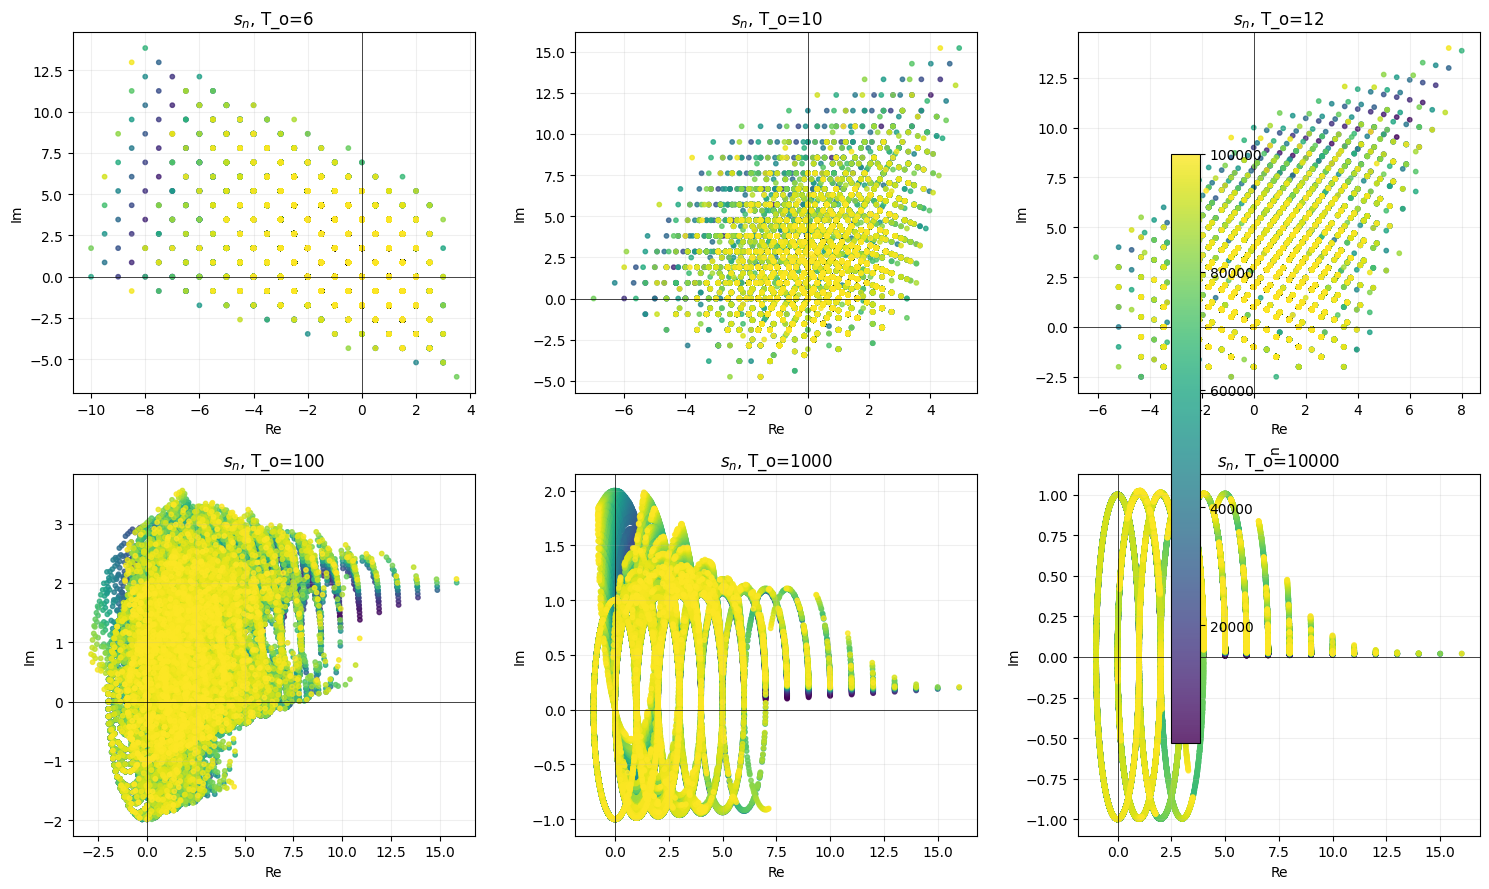

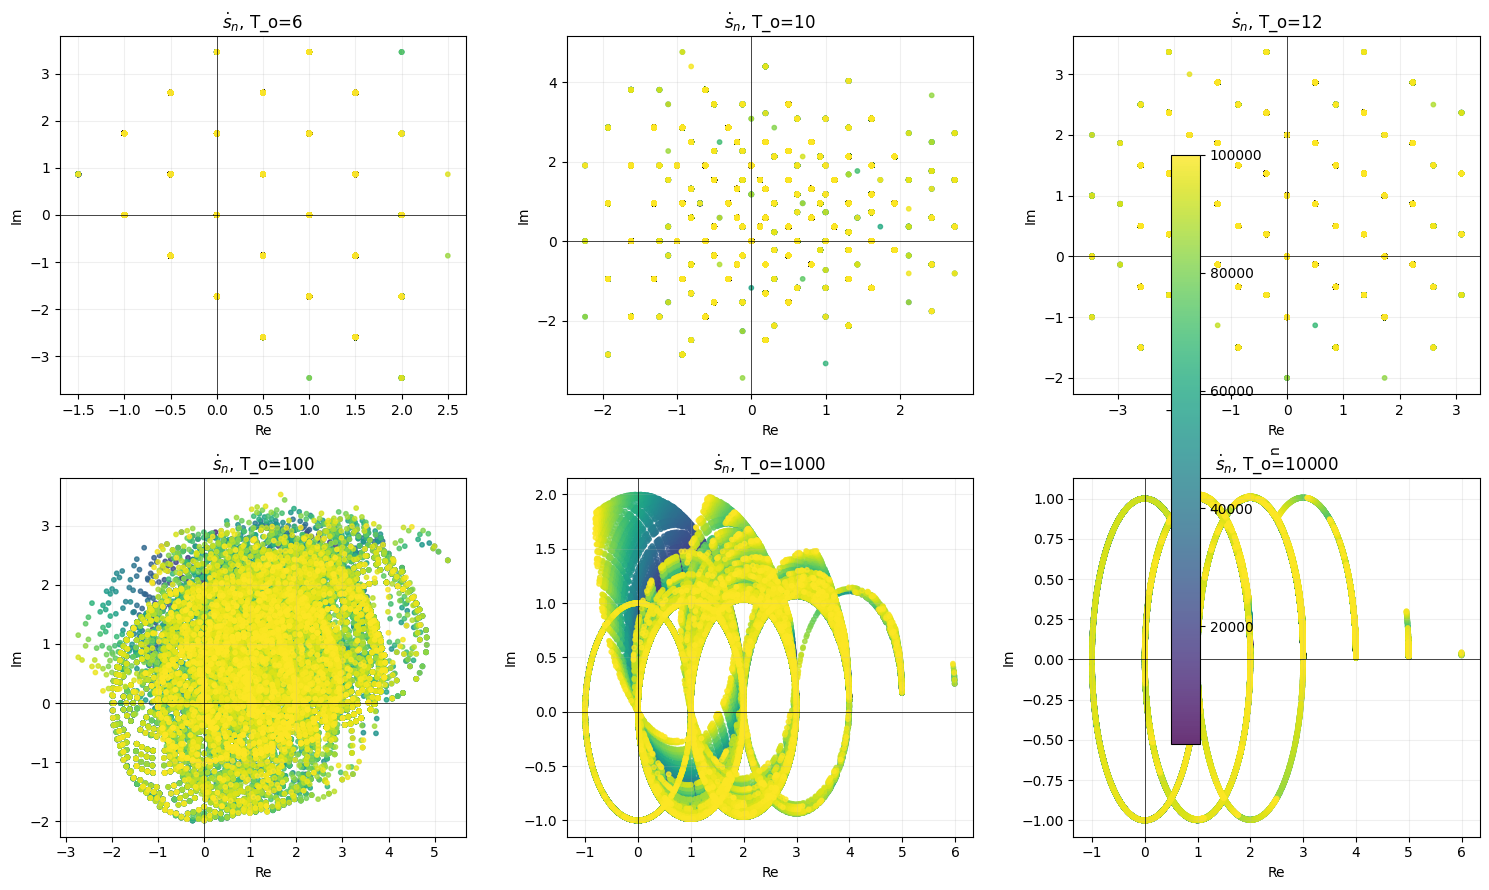

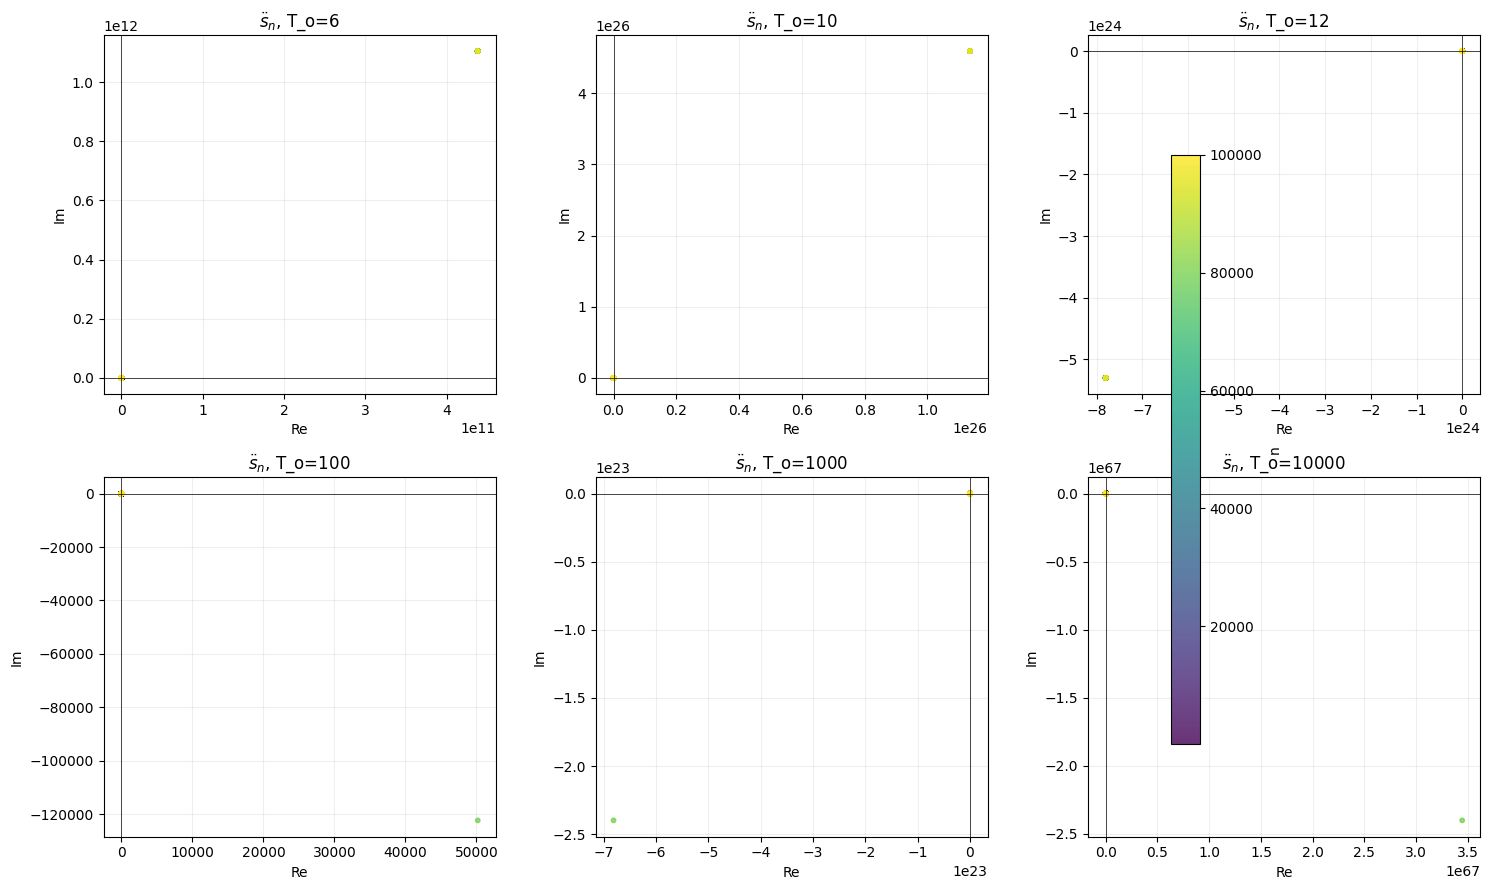

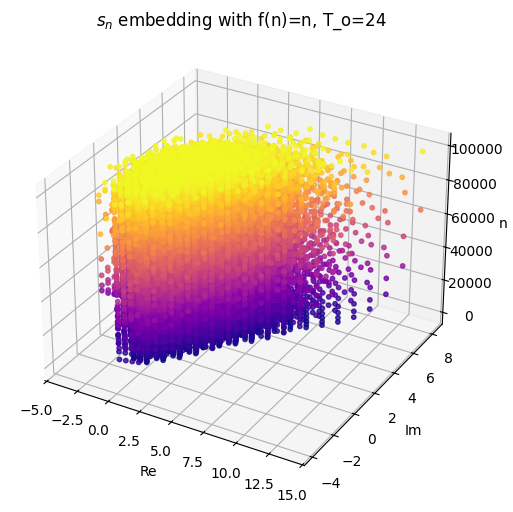

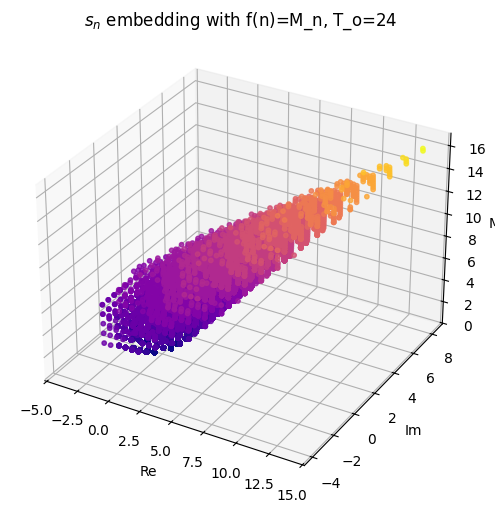

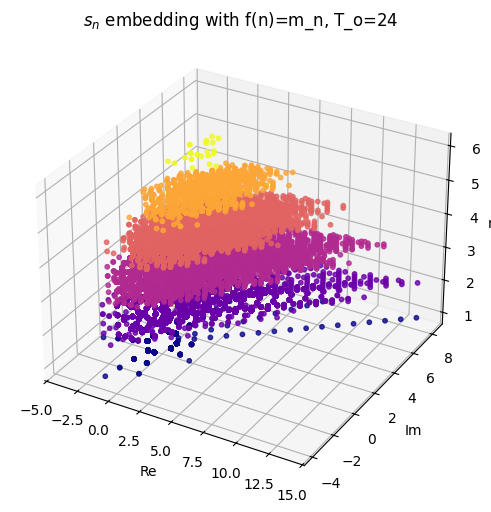

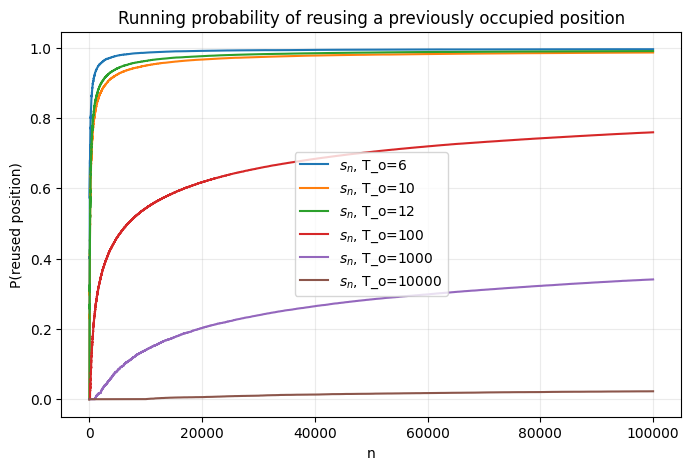

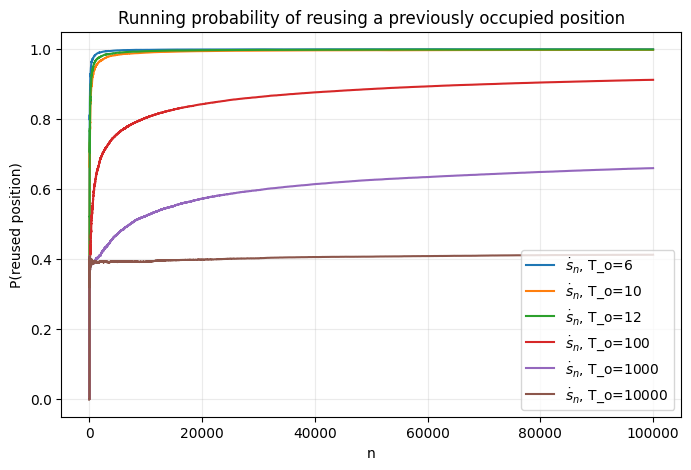

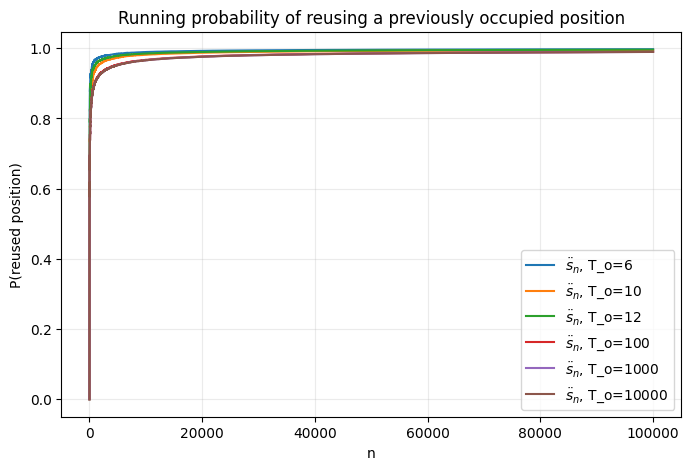

In [3]:
import numpy as np

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401


def prime_factorization(n: int) -> dict:
    """Return prime factorization of n as {prime: exponent}."""
    factors = {}
    x = n
    p = 2
    while p * p <= x:
        while x % p == 0:
            factors[p] = factors.get(p, 0) + 1
            x //= p
        p = 3 if p == 2 else p + 2  # skip even numbers after 2
    if x > 1:
        factors[x] = factors.get(x, 0) + 1
    return factors


def omega(T_o: float) -> complex:
    """Primitive phase base: ω = exp(2πi / T_o)."""
    return np.exp(2j * np.pi / T_o)


def factorization_notation(n: int):
    """
    Return notation components for n:
    - d_k: distinct prime factors (sorted)
    - e_k: corresponding exponents
    - M_n: total number of prime factors with multiplicity
    - m_n: number of distinct prime factors
    """
    f = prime_factorization(n)
    d_k = np.array(sorted(f.keys()), dtype=int)
    e_k = np.array([f[p] for p in d_k], dtype=int)
    M_n = int(e_k.sum())
    m_n = int(len(d_k))
    return d_k, e_k, M_n, m_n


def s_n(n: int, T_o: float) -> complex:
    """s_n = Σ_{k=1..m_n} e_k * ω^{d_k} (multiplicity weighted)."""
    d_k, e_k, _, _ = factorization_notation(n)
    w = omega(T_o)
    return np.sum(e_k * (w ** d_k))


def s_dot_n(n: int, T_o: float) -> complex:
    """ṡ_n = Σ_{k=1..m_n} ω^{d_k} (distinct prime factors only)."""
    d_k, _, _, _ = factorization_notation(n)
    w = omega(T_o)
    return np.sum(w ** d_k)


def s_ddot_n(n: int, T_o: float) -> complex:
    """s̈_n = Σ_{k=1..m_n} ω^{e_k^{d_k}} (distinct factors with exponent encoding)."""
    d_k, e_k, _, _ = factorization_notation(n)
    w = omega(T_o)
    return np.sum(w ** (e_k ** d_k))


def compute_sequence(N: int, T_o: float, mode: str = "s"):
    """
    Compute sequence values for n=2..N.
    mode in {'s', 'dot', 'ddot'}.
    """
    n_vals = np.arange(2, N + 1)

    if mode == "s":
        vals = np.array([s_n(n, T_o) for n in n_vals], dtype=complex)
        label = r"$s_n$"
    elif mode == "dot":
        vals = np.array([s_dot_n(n, T_o) for n in n_vals], dtype=complex)
        label = r"$\dot{s}_n$"
    elif mode == "ddot":
        vals = np.array([s_ddot_n(n, T_o) for n in n_vals], dtype=complex)
        label = r"$\ddot{s}_n$"
    else:
        raise ValueError("mode must be one of: 's', 'dot', 'ddot'")

    M_vals = np.array([factorization_notation(n)[2] for n in n_vals], dtype=int)
    m_vals = np.array([factorization_notation(n)[3] for n in n_vals], dtype=int)

    return n_vals, vals, M_vals, m_vals, label


def plot_complex_plane(n_vals, vals, title, connect=False):
    """2D complex-plane plot: Re vs Im."""
    plt.figure(figsize=(7, 6))
    plt.scatter(vals.real, vals.imag, c=n_vals, s=14, cmap="viridis", alpha=0.8)
    if connect:
        plt.plot(vals.real, vals.imag, lw=0.7, alpha=0.5, color="gray")
    plt.axhline(0, color="black", lw=0.7)
    plt.axvline(0, color="black", lw=0.7)
    plt.colorbar(label="n")
    plt.xlabel("Re")
    plt.ylabel("Im")
    plt.title(title)
    plt.grid(alpha=0.2)
    plt.show()


def plot_3d_embedding(vals, f_vals, title, f_label="f(n)"):
    """3D embedding (Re, Im, f(n))."""
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(vals.real, vals.imag, f_vals, c=f_vals, cmap="plasma", s=10, alpha=0.8)
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")
    ax.set_zlabel(f_label)
    ax.set_title(title)
    plt.show()


def occupancy_probabilities(vals, decimals=12):
    """
    Running probabilities:
    - P(reused position up to n)
    - P(new position up to n)
    """
    seen = set()
    reused_count = 0
    p_reused = []
    p_new = []

    for i, z in enumerate(vals, start=1):
        key = (round(float(z.real), decimals), round(float(z.imag), decimals))
        if key in seen:
            reused_count += 1
        else:
            seen.add(key)

        p_reused.append(reused_count / i)
        p_new.append(1.0 - p_reused[-1])

    return np.array(p_reused), np.array(p_new)


def plot_parameter_grid(N, T_o_values, mode="s"):
    """Compare complex plots for multiple T_o values."""
    n_cols = min(3, len(T_o_values))
    n_rows = int(np.ceil(len(T_o_values) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)

    for idx, T_o in enumerate(T_o_values):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]
        n_vals, vals, _, _, label = compute_sequence(N=N, T_o=T_o, mode=mode)
        sc = ax.scatter(vals.real, vals.imag, c=n_vals, s=10, cmap="viridis", alpha=0.8)
        ax.axhline(0, color="black", lw=0.5)
        ax.axvline(0, color="black", lw=0.5)
        ax.set_title(f"{label}, T_o={T_o}")
        ax.set_xlabel("Re")
        ax.set_ylabel("Im")
        ax.grid(alpha=0.2)

    # Hide unused axes
    for j in range(len(T_o_values), n_rows * n_cols):
        r, c = divmod(j, n_cols)
        axes[r, c].axis("off")

    fig.colorbar(sc, ax=axes.ravel().tolist(), label="n", shrink=0.85)
    plt.tight_layout()
    plt.show()


def plot_reuse_vs_new(N, T_o_values, mode="s"):
    """Plot running reused/new-position probabilities across parameters."""
    plt.figure(figsize=(8, 5))
    for T_o in T_o_values:
        n_vals, vals, _, _, label = compute_sequence(N=N, T_o=T_o, mode=mode)
        p_reused, _ = occupancy_probabilities(vals)
        plt.plot(n_vals, p_reused, label=f"{label}, T_o={T_o}")

    plt.xlabel("n")
    plt.ylabel("P(reused position)")
    plt.title("Running probability of reusing a previously occupied position")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.show()


# ----------------------------
# Example exploration settings
# ----------------------------
N = 10**5
T_o_values = [6, 10, 12, 10**2, 10**3,10**4]

# 1) Compare complex-plane patterns for s_n, s_dot_n, s_ddot_n
plot_parameter_grid(N=N, T_o_values=T_o_values, mode="s")
plot_parameter_grid(N=N, T_o_values=T_o_values, mode="dot")
plot_parameter_grid(N=N, T_o_values=T_o_values, mode="ddot")

# 2) 3D embeddings for one parameter (f(n)=n, M_n, m_n)
T_o_demo = 24
n_vals, vals_s, M_vals, m_vals, label_s = compute_sequence(N=N, T_o=T_o_demo, mode="s")
plot_3d_embedding(vals_s, n_vals, title=f"{label_s} embedding with f(n)=n, T_o={T_o_demo}", f_label="n")
plot_3d_embedding(vals_s, M_vals, title=f"{label_s} embedding with f(n)=M_n, T_o={T_o_demo}", f_label="M_n")
plot_3d_embedding(vals_s, m_vals, title=f"{label_s} embedding with f(n)=m_n, T_o={T_o_demo}", f_label="m_n")

# 3) Occupancy/reuse probabilities across parameters
plot_reuse_vs_new(N=N, T_o_values=T_o_values, mode="s")
plot_reuse_vs_new(N=N, T_o_values=T_o_values, mode="dot")
plot_reuse_vs_new(N=N, T_o_values=T_o_values, mode="ddot")

In [ ]:

# ============================================================
# Interactive Exploration — ipywidgets controls
# Run the cell above first to define all functions, then run
# this cell and use the buttons to generate plots on demand.
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

_W = {'description_width': 'initial'}
_LAYOUT = widgets.Layout(width='480px')
_TO_OPTIONS = [6, 10, 12, 100, 1000, 10000]

# ── Shared: N (number of integers evaluated) ─────────────────
w_N = widgets.IntSlider(
    value=1000, min=100, max=50000, step=100,
    description='N (# integers):', continuous_update=False,
    style=_W, layout=_LAYOUT)

def _mode_dd(desc='Mode:'):
    return widgets.Dropdown(
        options=[('s_n  — weighted by multiplicity', 's'),
                 ('ṡ_n — distinct primes only',      'dot'),
                 ('s̈_n — prime powers p^e',          'ddot')],
        value='s', description=desc, style=_W)

def _to_text(val=10, desc='T₀:'):
    return widgets.FloatText(
        value=val, description=desc, style=_W,
        layout=widgets.Layout(width='220px'))

def _to_multi(desc='T₀ list (multi-select):'):
    return widgets.SelectMultiple(
        options=_TO_OPTIONS, value=tuple(_TO_OPTIONS),
        description=desc, rows=len(_TO_OPTIONS), style=_W)

# ── Section 1: Complex plane — single T₀ ─────────────────────
_mode1 = _mode_dd('Mode:')
_to1   = _to_text(10, 'T₀:')
_out1  = widgets.Output()
_btn1  = widgets.Button(description='▶ Plot Complex Plane',
                        button_style='info',
                        layout=widgets.Layout(width='220px'))

def _run1(_):
    with _out1:
        clear_output(wait=True)
        n_v, vals, Mn, mn, lbl = compute_sequence(
            N=w_N.value, T_o=_to1.value, mode=_mode1.value)
        plot_complex_plane(
            n_v, vals,
            f"{lbl},  T₀={_to1.value},  N={w_N.value}",
            connect=False)

_btn1.on_click(_run1)

# ── Section 2: Parameter grid — multiple T₀ ──────────────────
_mode2 = _mode_dd('Mode (grid):')
_to2   = _to_multi('T₀ list:')
_out2  = widgets.Output()
_btn2  = widgets.Button(description='▶ Plot Parameter Grid',
                        button_style='info',
                        layout=widgets.Layout(width='220px'))

def _run2(_):
    with _out2:
        clear_output(wait=True)
        T_os = list(_to2.value) or [10]
        plot_parameter_grid(N=w_N.value, T_o_values=T_os, mode=_mode2.value)

_btn2.on_click(_run2)

# ── Section 3: 3D embedding ───────────────────────────────────
_mode3 = _mode_dd('Mode (3D):')
_to3   = _to_text(24, 'T₀ (3D):')
_f3    = widgets.Dropdown(
    options=[('f(n) = n',                    'n'),
             ('f(n) = M_n  (Ω, big omega)',  'M_n'),
             ('f(n) = m_n  (ω, small omega)', 'm_n')],
    value='n', description='Z-axis f(n):', style=_W)
_out3  = widgets.Output()
_btn3  = widgets.Button(description='▶ Plot 3D Embedding',
                        button_style='info',
                        layout=widgets.Layout(width='220px'))

def _run3(_):
    with _out3:
        clear_output(wait=True)
        n_v, vals, Mn, mn, lbl = compute_sequence(
            N=w_N.value, T_o=_to3.value, mode=_mode3.value)
        choice = _f3.value
        if   choice == 'n':   f_vals, f_lbl = n_v, 'n'
        elif choice == 'M_n': f_vals, f_lbl = Mn,  'M_n (Ω)'
        else:                 f_vals, f_lbl = mn,  'm_n (ω)'
        plot_3d_embedding(
            vals, f_vals,
            title=f"{lbl},  T₀={_to3.value},  N={w_N.value},  z={f_lbl}",
            f_label=f_lbl)

_btn3.on_click(_run3)

# ── Section 4: Occupancy / reuse probability ─────────────────
_mode4 = _mode_dd('Mode (reuse):')
_to4   = _to_multi('T₀ list:')
_out4  = widgets.Output()
_btn4  = widgets.Button(description='▶ Plot Reuse Probability',
                        button_style='info',
                        layout=widgets.Layout(width='220px'))

def _run4(_):
    with _out4:
        clear_output(wait=True)
        T_os = list(_to4.value) or [10]
        plot_reuse_vs_new(N=w_N.value, T_o_values=T_os, mode=_mode4.value)

_btn4.on_click(_run4)

# ── Layout ────────────────────────────────────────────────────
_sep = lambda: widgets.HTML('<hr style="border-color:#aaa;margin:8px 0">')

display(widgets.VBox([
    widgets.HTML('<h3>🔧 Interactive Exploration</h3>'),
    widgets.HTML('<b>Shared parameter</b>'),
    w_N,

    _sep(),
    widgets.HTML('<h4>1 · Complex Plane  (single T₀)</h4>'),
    widgets.HBox([_to1, _mode1]),
    _btn1, _out1,

    _sep(),
    widgets.HTML('<h4>2 · Parameter Grid  (multiple T₀, one mode)</h4>'),
    widgets.HBox([_to2, widgets.VBox([_mode2, _btn2])]),
    _out2,

    _sep(),
    widgets.HTML('<h4>3 · 3D Embedding  (single T₀, choose Z-axis)</h4>'),
    widgets.HBox([_to3, widgets.VBox([_mode3, _f3, _btn3])]),
    _out3,

    _sep(),
    widgets.HTML('<h4>4 · Occupancy / Reuse Probability  (multiple T₀, one mode)</h4>'),
    widgets.HBox([_to4, widgets.VBox([_mode4, _btn4])]),
    _out4,
]))
